STEP 1 — LOADING DATASET
Dataset loaded successfully!
Dataset shape: (5572, 2)

First 5 rows:


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."



STEP 2 — EXPLORATORY DATA ANALYSIS

Class Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


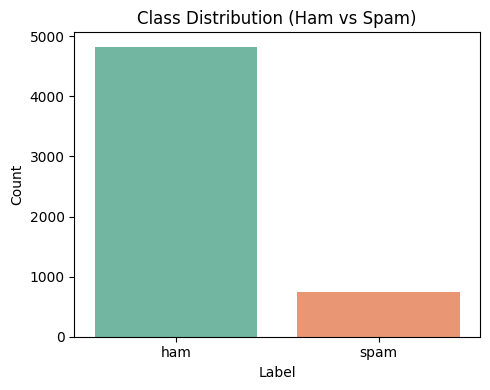


Average message length:
label
Ham      71.482487
Spam    138.670683
Name: msg_length, dtype: float64


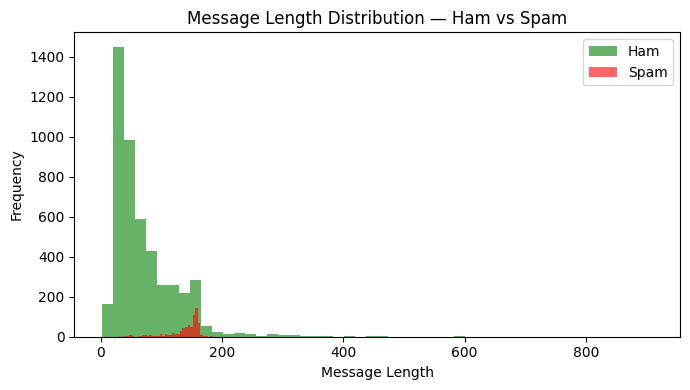


STEP 3 — NLP PREPROCESSING
Text cleaning done!

Sample before and after cleaning:


,message,cleaned_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah think go usf life around though



STEP 4 — ENCODING LABELS
Labels encoded — ham = 0, spam = 1
label
0    4825
1     747
Name: count, dtype: int64

STEP 5 — TF-IDF VECTORIZATION
TF-IDF vectorization done!
Train shape: (4457, 5000)
Test shape : (1115, 5000)

STEP 6 — TRAINING MODEL
Model trained successfully!

STEP 7 — EVALUATION
Train Accuracy : 0.9825
Test Accuracy  : 0.9767

Classification Report:
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.99       966
        Spam       1.00      0.83      0.90       149

    accuracy                           0.98      1115
   macro avg       0.99      0.91      0.95      1115
weighted avg       0.98      0.98      0.98      1115



<Figure size 500x400 with 0 Axes>

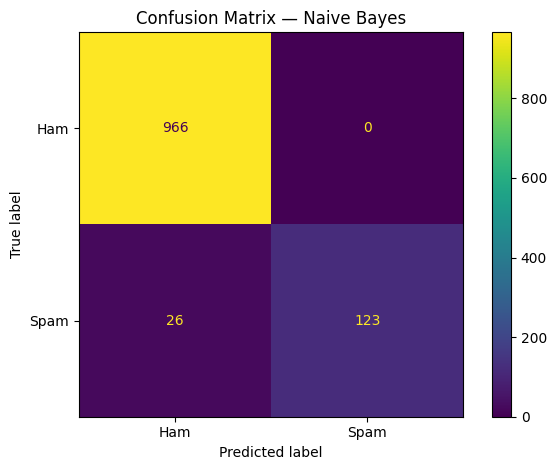


STEP 8 — CROSS VALIDATION
5-Fold Cross Validation Results:
  Accuracy : 0.9708
  Std Dev  : (+/- 0.0093)

STEP 9 — LIVE PREDICTIONS

Message : Congratulations! You have won a free iPhone. Click here to claim now.
Result  : Spam

Message : Hey, are you coming to class tomorrow?
Result  : Ham (Not Spam)

Message : URGENT: Your bank account has been compromised. Call now!
Result  : Ham (Not Spam)

Message : Free entry to win a cash prize! Call now!
Result  : Spam

Message : Can we reschedule our meeting to 3pm?
Result  : Ham (Not Spam)


In [2]:
# ============================================================
# SPAM DETECTION
# Dataset: SMS Spam Collection (UCI) - loaded directly from URL
# Model: Multinomial Naive Bayes + TF-IDF
# ============================================================

# IMPORTING LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

# ============================================================
# STEP 1 — LOAD DATASET
# ============================================================
print("="*50)
print("STEP 1 — LOADING DATASET")
print("="*50)

url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
df = pd.read_csv(url, sep='\t', header=None, names=['label', 'message'])

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

# ============================================================
# STEP 2 — EDA
# ============================================================
print("\n" + "="*50)
print("STEP 2 — EXPLORATORY DATA ANALYSIS")
print("="*50)

print("\nClass Distribution:")
print(df['label'].value_counts())

# Class distribution plot
plt.figure(figsize=(5, 4))
sns.countplot(x='label', data=df, hue='label', palette='Set2', legend=False)
plt.title('Class Distribution (Ham vs Spam)')
plt.xlabel('Label')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Message length distribution
df['msg_length'] = df['message'].apply(len)
print("\nAverage message length:")
print(df.groupby('label')['msg_length'].mean().rename({'ham': 'Ham', 'spam': 'Spam'}))

plt.figure(figsize=(7, 4))
df[df['label'] == 'ham']['msg_length'].plot(kind='hist', bins=50, alpha=0.6, label='Ham', color='green')
df[df['label'] == 'spam']['msg_length'].plot(kind='hist', bins=50, alpha=0.6, label='Spam', color='red')
plt.legend()
plt.title('Message Length Distribution — Ham vs Spam')
plt.xlabel('Message Length')
plt.tight_layout()
plt.show()

# ============================================================
# STEP 3 — NLP PREPROCESSING
# Steps: lowercase, remove special chars, remove stopwords, lemmatize
# ============================================================
print("\n" + "="*50)
print("STEP 3 — NLP PREPROCESSING")
print("="*50)

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub('[^a-zA-Z]', ' ', text)
    tokens = text.split()
    cleaned = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(cleaned)

df['cleaned_message'] = df['message'].apply(clean_text)

print("Text cleaning done!")
print("\nSample before and after cleaning:")
display(df[['message', 'cleaned_message']].head())

# ============================================================
# STEP 4 — ENCODE LABELS
# ham = 0, spam = 1
# ============================================================
print("\n" + "="*50)
print("STEP 4 — ENCODING LABELS")
print("="*50)

df['label'] = df['label'].map({'ham': 0, 'spam': 1})
print("Labels encoded — ham = 0, spam = 1")
print(df['label'].value_counts())

# ============================================================
# STEP 5 — TF-IDF VECTORIZATION & TRAIN TEST SPLIT
# fit_transform on train only, transform on test — prevents data leakage
# ============================================================
print("\n" + "="*50)
print("STEP 5 — TF-IDF VECTORIZATION")
print("="*50)

X = df['cleaned_message']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

vectorizer = TfidfVectorizer(max_features=5000, lowercase=False, ngram_range=(1, 2))

vec_train = vectorizer.fit_transform(X_train)
vec_test = vectorizer.transform(X_test)

print("TF-IDF vectorization done!")
print("Train shape:", vec_train.shape)
print("Test shape :", vec_test.shape)

# ============================================================
# STEP 6 — TRAIN MODEL
# Multinomial Naive Bayes — best suited for text classification
# ============================================================
print("\n" + "="*50)
print("STEP 6 — TRAINING MODEL")
print("="*50)

clf = MultinomialNB()
clf.fit(vec_train, y_train)
print("Model trained successfully!")

# ============================================================
# STEP 7 — EVALUATION
# Accuracy, Precision, Recall, F1, Confusion Matrix
# ============================================================
print("\n" + "="*50)
print("STEP 7 — EVALUATION")
print("="*50)

y_pred = clf.predict(vec_test)

print(f"Train Accuracy : {accuracy_score(y_train, clf.predict(vec_train)):.4f}")
print(f"Test Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

plt.figure(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Ham', 'Spam'])
plt.title('Confusion Matrix — Naive Bayes')
plt.tight_layout()
plt.show()

# ============================================================
# STEP 8 — CROSS VALIDATION
# ============================================================
print("\n" + "="*50)
print("STEP 8 — CROSS VALIDATION")
print("="*50)

scores = cross_val_score(clf, vec_train, y_train, cv=5)
print("5-Fold Cross Validation Results:")
print(f"  Accuracy : {np.mean(scores):.4f}")
print(f"  Std Dev  : (+/- {np.std(scores)*2:.4f})")

# ============================================================
# STEP 9 — LIVE PREDICTIONS
# Testing on example messages — no input() to avoid freezing
# ============================================================
print("\n" + "="*50)
print("STEP 9 — LIVE PREDICTIONS")
print("="*50)

def predict_message(text):
    cleaned = clean_text(text)
    vectorized = vectorizer.transform([cleaned])
    prediction = clf.predict(vectorized)
    return "Spam" if prediction[0] == 1 else "Ham (Not Spam)"

test_messages = [
    "Congratulations! You have won a free iPhone. Click here to claim now.",
    "Hey, are you coming to class tomorrow?",
    "URGENT: Your bank account has been compromised. Call now!",
    "Free entry to win a cash prize! Call now!",
    "Can we reschedule our meeting to 3pm?"
]

for msg in test_messages:
    print(f"\nMessage : {msg}")
    print(f"Result  : {predict_message(msg)}")